In [1]:
import utils
import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import pandas as pd
import numpy as np

In [176]:
columns = ("model", "lighting", "year")
(train_x, train_y), (test_x, test_y) = utils.read_stratified_data(columns=columns, strata_threshold=38)

datasett/275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg /data/upload/3/bb413a1b-275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg
datasett/black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg /data/upload/3/e82f4a47-black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg
datasett/kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png /data/upload/3/5e846c95-kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png
datasett/Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg /data/upload/3/c94577a6-Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg


In [177]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(3703, 300, 300, 3)
(3703, 5)
(632, 300, 300, 3)
(632, 5)


In [178]:
strata_train = train_y[list(columns)]\
    .fillna('')\
    .astype(str)\
    .agg('-'.join, axis=1).value_counts().sort_values()

strata_test = test_y[list(columns)]\
    .fillna('')\
    .astype(str)\
    .agg('-'.join, axis=1).value_counts().sort_values()

comparison = pd.DataFrame({
    'treningssett': strata_train,
    'testsett': strata_test
})

comparison = comparison.fillna(0).astype(int)

comparison['train_%'] = (comparison['treningssett'] / comparison['treningssett'].sum() * 100).round(2)
comparison['test_%'] = (comparison['testsett'] / comparison['testsett'].sum() * 100).round(2)

comparison = comparison.sort_values(by='testsett')

print(comparison)

                    treningssett  testsett  train_%  test_%
X-Dark-2021–nå                 6         0     0.16    0.00
S-Medium-2016–2020            17         0     0.46    0.00
S-Medium-2012–2015            11         0     0.30    0.00
X-Medium-2021–nå               1         0     0.03    0.00
S-Dark-2016–2020              15         0     0.41    0.00
S-Dark-2012–2015               9         0     0.24    0.00
X-Medium-2016–2020            24         0     0.65    0.00
X-Dark-2016–2020              37         0     1.00    0.00
S-Light-2016–2020             41         7     1.11    1.11
S-Light-2021–nå               46         8     1.24    1.27
X-Light-2021–nå               50         9     1.35    1.42
Y-Light-2025-nå               56        10     1.51    1.58
3-Medium-2024–nå              66        12     1.78    1.90
3-Dark-2024–nå                67        12     1.81    1.90
S-Light-2012–2015             75        13     2.03    2.06
3-Light-2024–nå               76        

In [5]:
i = 0

color       Black/Dark gray
lighting             Medium
model                     X
year              2016–2020
source             internal
Name: 1628, dtype: str


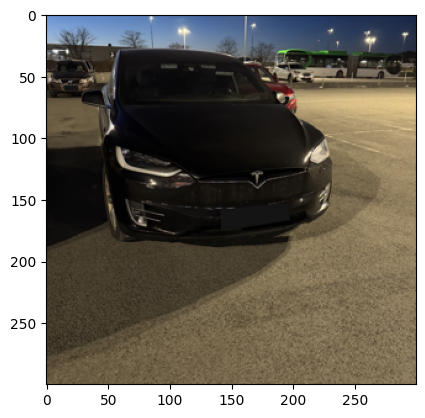

In [167]:
print(train_y.iloc[i])
plt.imshow(train_x[i])
plt.show()
i += 1

In [8]:
train_y_new = train_y["model"]

def t(x):
    if x == 'Other car':
        return 1
    return 0

vt = np.vectorize(t)

train_y_new = vt(train_y_new)

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)
    return keras.Model(inputs, outputs) 

functional_model = make_model(train_x[0].shape, 1)

epochs = 5

functional_model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

functional_model.fit(
    train_x,
    train_y_new,
    epochs=epochs,
)

I0000 00:00:1771527874.045418    3916 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9569 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/5


I0000 00:00:1771527879.904954    4864 service.cc:148] XLA service 0x7922f8005130 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771527879.906268    4864 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-02-19 20:04:39.977620: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771527880.148196    4864 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/116 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5349 - loss: 0.7612

I0000 00:00:1771527885.572427    4864 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


116/116 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.7204 - loss: 0.5602
Epoch 2/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8227 - loss: 0.4068
Epoch 3/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8734 - loss: 0.3119
Epoch 4/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9154 - loss: 0.2248
Epoch 5/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9474 - loss: 0.1570


In [9]:
test_y_new = test_y["model"]
test_y_new = vt(test_y_new)

functional_model.evaluate(test_x, test_y_new)

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8145 - loss: 0.4398


[0.43980175256729126, 0.8145285844802856]

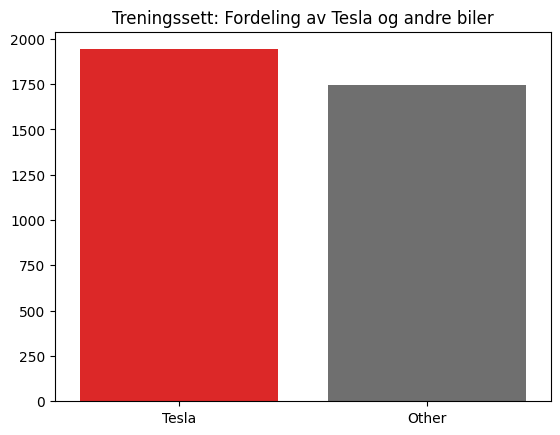

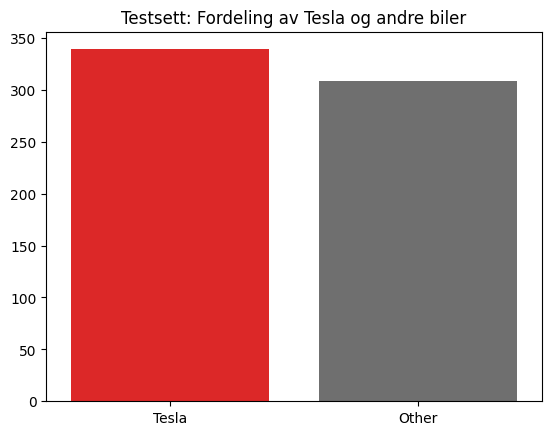

In [10]:
df = train_y
other = 'Other car'

names = ['Tesla', 'Other']
counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
plot.set_title(f'Treningssett: Fordeling av Tesla og andre biler')
plt.show()

df = test_y
names = ['Tesla', 'Other']
counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
plot.set_title(f'Testsett: Fordeling av Tesla og andre biler')
plt.show()

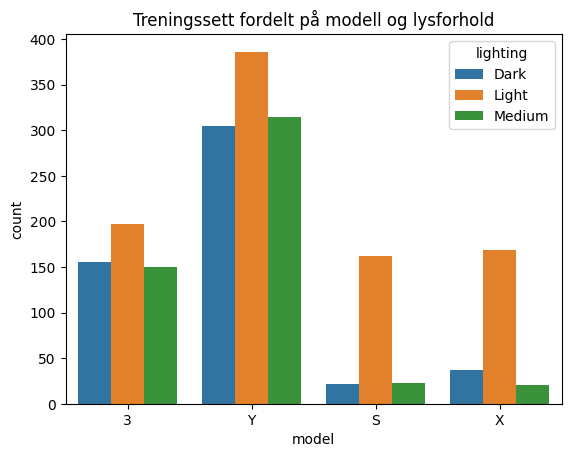

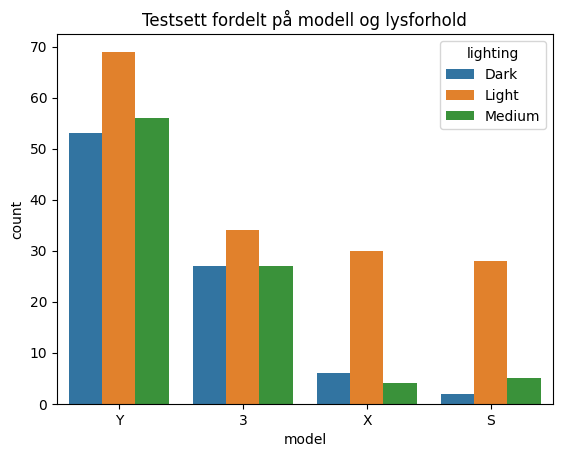

In [19]:
df = train_y
other = 'Other car'
tesla = df[df['model'] != other].sort_values(by="model").sort_values(by="lighting")

sns.countplot(data=tesla, x="model", hue="lighting").set_title("Treningssett fordelt på modell og lysforhold")
plt.show()

df = test_y
tesla = df[df['model'] != other].sort_values(by="model").sort_values(by="lighting")

sns.countplot(data=tesla, x="model", hue="lighting").set_title("Testsett fordelt på modell og lysforhold")
plt.show()

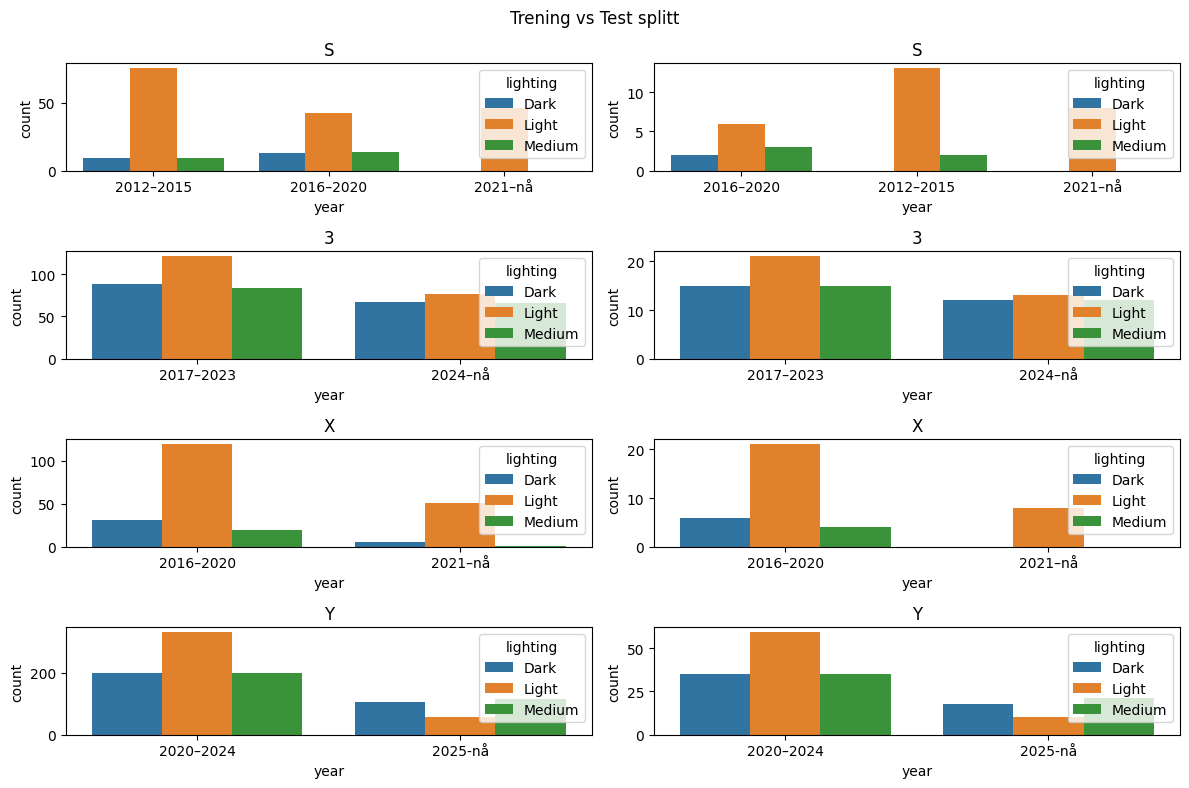

In [12]:
train_y_split = [
    train_y[train_y['model'] == 'S'].sort_values('year').sort_values('lighting', kind='stable'),
    train_y[train_y['model'] == '3'].sort_values('year').sort_values('lighting', kind='stable'),
    train_y[train_y['model'] == 'X'].sort_values('year').sort_values('lighting', kind='stable'),
    train_y[train_y['model'] == 'Y'].sort_values('year').sort_values('lighting', kind='stable')
]
test_y_split = [
    test_y[test_y['model'] == 'S'].sort_values('year').sort_values('lighting', kind='stable'),
    test_y[test_y['model'] == '3'].sort_values('year').sort_values('lighting', kind='stable'),
    test_y[test_y['model'] == 'X'].sort_values('year').sort_values('lighting', kind='stable'),
    test_y[test_y['model'] == 'Y'].sort_values('year').sort_values('lighting', kind='stable')
]

models = ["S", "3", "X", "Y"]
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
fig.suptitle(f'Trening vs Test splitt')
for i in range(0,2):
    for j in range(0,2):
        sns.countplot(x='year', data=train_y_split[i*2 + j], ax=axes[i*2+j,0], hue='lighting')
        axes[i*2+j,0].title.set_text(models[i*2 + j])
        sns.countplot(x='year', data=test_y_split[i*2 + j], ax=axes[i*2+j,1], hue='lighting')
        axes[i*2+j,1].title.set_text(models[i*2 + j])

plt.tight_layout()
plt.show()

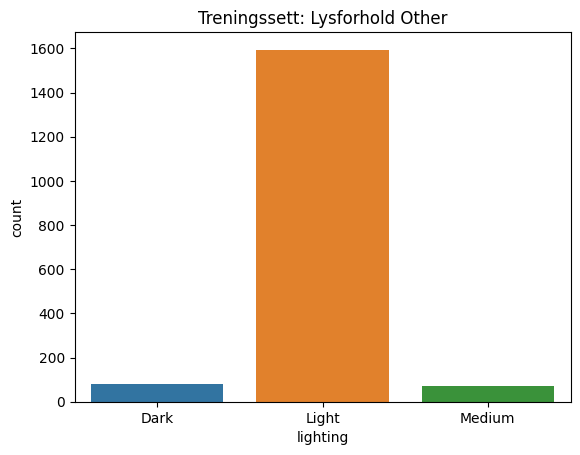

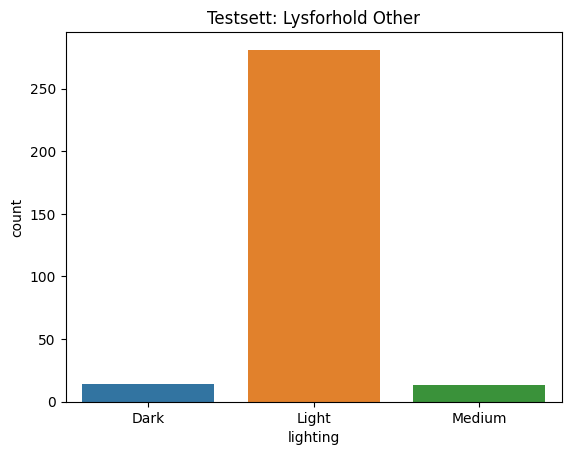

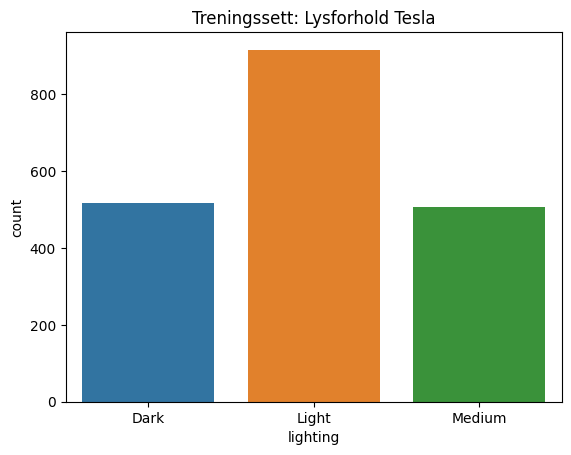

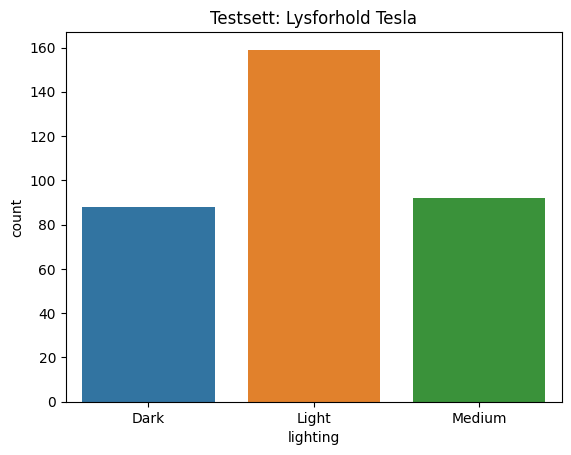

In [13]:
df = train_y[train_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Other')
plt.show()

df = test_y[test_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Other')
plt.show()

df = train_y[train_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()

df = test_y[test_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Tesla')
plt.show()